<a href="https://colab.research.google.com/github/ajaynunna/Major-project---Online-gaming/blob/main/Major_projects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Topic: Predictive analysis of player engagement and retention.

Dataset : https://www.kaggle.com/datasets/rabieelkharoua/predict-online-gaming-behavior-dataset

Research Question: Can player behavioral metrics predict their Engagement Level (High/Medium/Low), and what are the strongest predictors?

Goal: Develop a classification model to accurately predict player engagement for the purpose of improving retention and optimizing game design.


# Load Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Dataset filepath  from github raw data
import pandas as pd
DATA_PATH = 'https://raw.githubusercontent.com/ajaynunna/Major-project---Online-gaming/refs/heads/main/online_gaming_behavior_dataset.csv'
df = pd.read_csv(DATA_PATH)
df.head()

Mounted at /content/drive


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


#Basic Dataset Inspection

In [2]:
# Basic info of dataset
df.info()

# Summary statistics
df.describe(include='all').T

# Checking missing values
df.isna().sum()

# checking Target distribution
df['EngagementLevel'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

,count
EngagementLevel,
Medium,19374
High,10336
Low,10324


In [3]:
# Missing value summary table
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent
}).sort_values('missing_count', ascending=False)

missing_df


,missing_count,missing_percent
PlayerID,0,0.0
Age,0,0.0
Gender,0,0.0
Location,0,0.0
GameGenre,0,0.0
PlayTimeHours,0,0.0
InGamePurchases,0,0.0
GameDifficulty,0,0.0
SessionsPerWeek,0,0.0
AvgSessionDurationMinutes,0,0.0


#Exploratory Data Analysis (EDA)

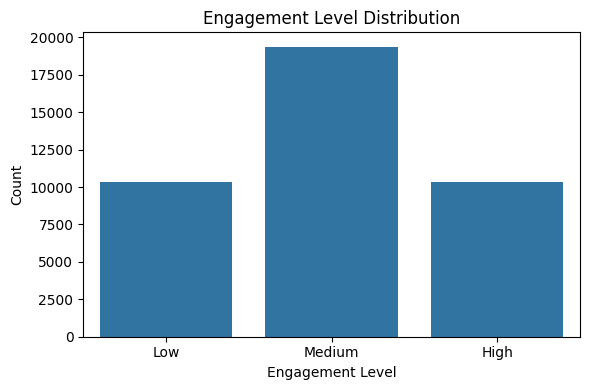

EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


In [4]:
#Engagement Level Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='EngagementLevel', data=df, order=['Low','Medium','High'])
plt.title('Engagement Level Distribution')
plt.ylabel('Count')
plt.xlabel('Engagement Level')
plt.tight_layout()
plt.show()

# numeric counts
print(df['EngagementLevel'].value_counts())

## Feature vs Engagement

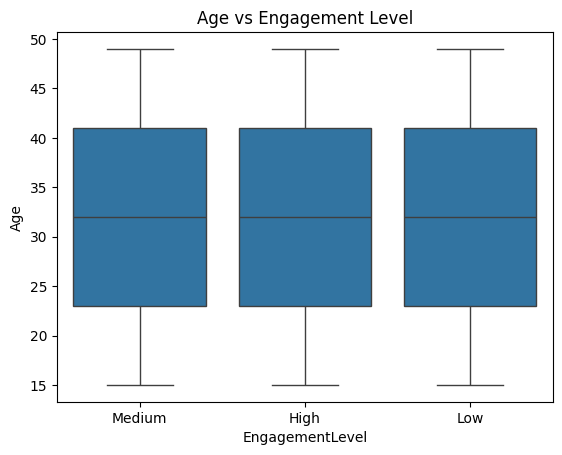

In [5]:
# Age vs Engagement
sns.boxplot(x='EngagementLevel', y='Age', data=df)
plt.title("Age vs Engagement Level")
plt.show()


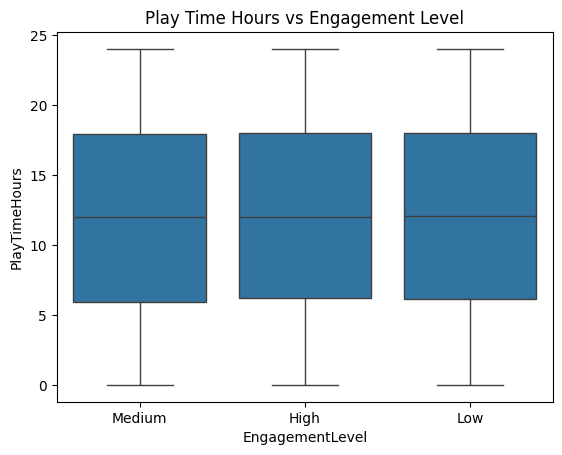

In [6]:
#Play Time Hours vs Engagement Level

sns.boxplot(x='EngagementLevel', y='PlayTimeHours', data=df)
plt.title("Play Time Hours vs Engagement Level")
plt.show()


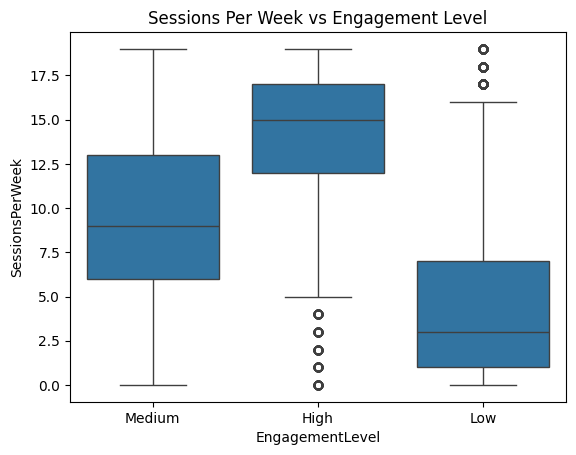

In [7]:
#Sessions Per Week vs Engagement Level

sns.boxplot(x='EngagementLevel', y='SessionsPerWeek', data=df)
plt.title("Sessions Per Week vs Engagement Level")
plt.show()


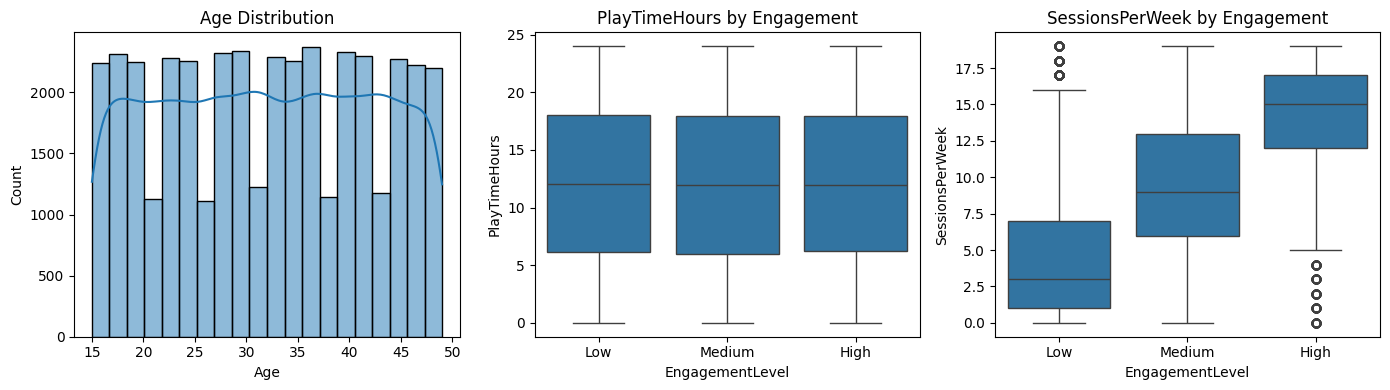

In [8]:
# Age dist + PlayTimeHours vs Engagement + SessionsPerWeek vs Engagement
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Age Distribution')

plt.subplot(1,3,2)
sns.boxplot(x='EngagementLevel', y='PlayTimeHours', data=df, order=['Low','Medium','High'])
plt.title('PlayTimeHours by Engagement')

plt.subplot(1,3,3)
sns.boxplot(x='EngagementLevel', y='SessionsPerWeek', data=df, order=['Low','Medium','High'])
plt.title('SessionsPerWeek by Engagement')

plt.tight_layout()
plt.show()

# Feature Engineering

In [9]:
# Feature Engineering - creating new features that improves the prediction accuracy

# total weekly playtime
df['TotalPlayPerWeek'] = df['PlayTimeHours'] * df['SessionsPerWeek']

# Age groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 17, 25, 40, 60, 100],
    labels=['Teen', 'YoungAdult', 'Adult', 'MidAge', 'Senior']
)

df.head()


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel,TotalPlayPerWeek,AgeGroup
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium,97.626713,MidAge
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium,27.629807,Adult
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High,131.580084,YoungAdult
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium,47.388161,Adult
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium,31.063889,Adult


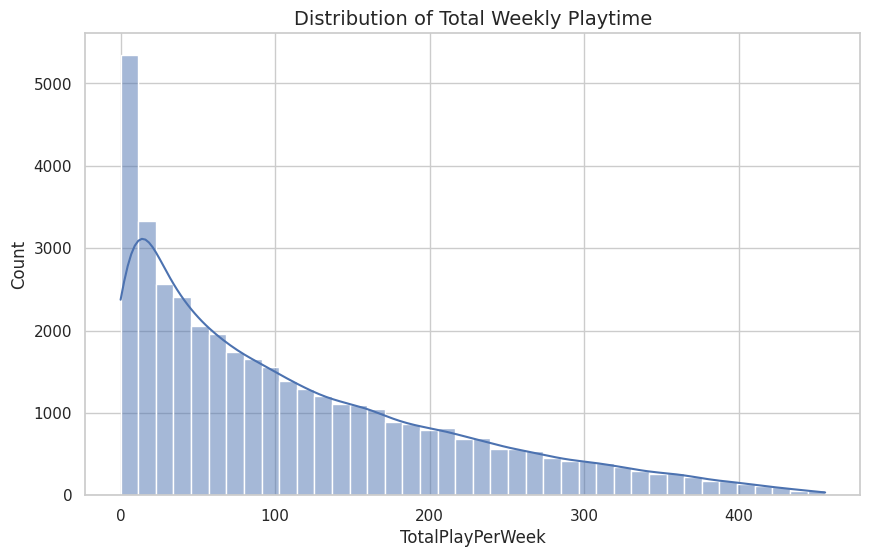

In [10]:

#Distribution of TotalPlayPerWeek

import matplotlib.pyplot as plt
import seaborn as sns

# Setting plot style
sns.set(style="whitegrid")


# Distribution of TotalPlayPerWeek

plt.figure(figsize=(10, 6))
sns.histplot(df['TotalPlayPerWeek'], bins=40, kde=True)
plt.title("Distribution of Total Weekly Playtime", fontsize=14)
plt.xlabel("TotalPlayPerWeek")
plt.ylabel("Count")
plt.show()




/tmp/ipython-input-1285280339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="EngagementLevel", y="TotalPlayPerWeek", palette="Set2")


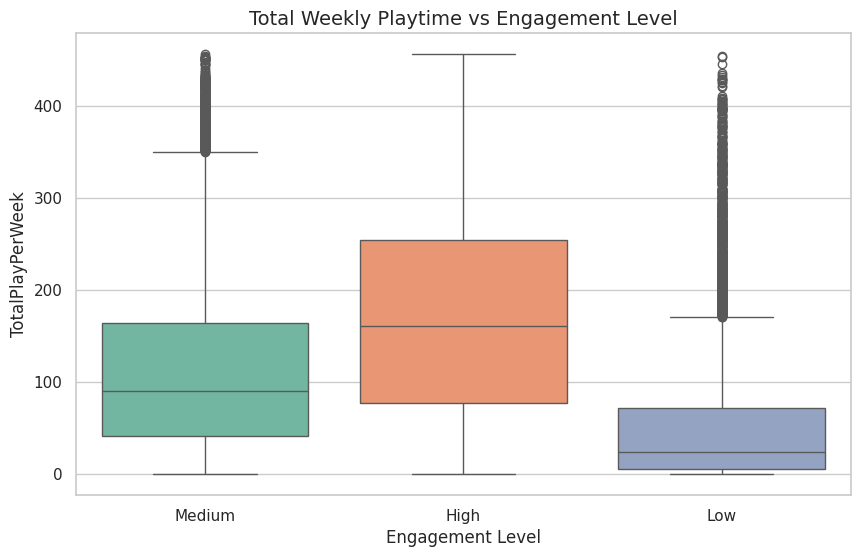

In [11]:
# TotalPlayPerWeek vs EngagementLevel
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="EngagementLevel", y="TotalPlayPerWeek", palette="Set2")
plt.title("Total Weekly Playtime vs Engagement Level", fontsize=14)
plt.xlabel("Engagement Level")
plt.ylabel("TotalPlayPerWeek")
plt.show()


/tmp/ipython-input-4007868161.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="AgeGroup", palette="Set3")


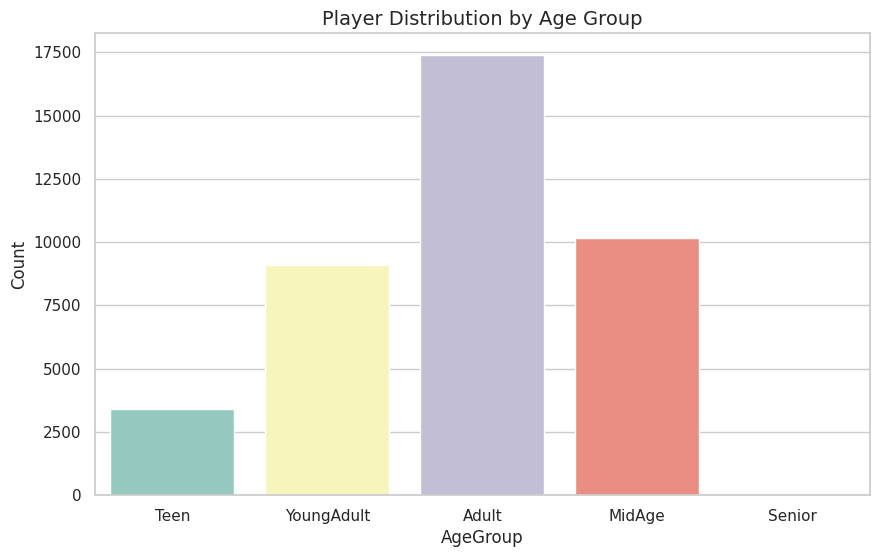

In [12]:
# Player Count by AgeGroup

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="AgeGroup", palette="Set3")
plt.title("Player Distribution by Age Group", fontsize=14)
plt.xlabel("AgeGroup")
plt.ylabel("Count")
plt.show()


# Preprocessing (Encoding + Scaling)

In [13]:
#  Separate Features and Target Variable

X = df.drop("EngagementLevel", axis=1)   # Features
y = df["EngagementLevel"]                # Target

In [14]:
# Identify Numerical and Categorical Columns

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

numerical_cols, categorical_cols


(Index(['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases',
        'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel',
        'AchievementsUnlocked', 'TotalPlayPerWeek'],
       dtype='object'),
 Index(['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'AgeGroup'], dtype='object'))

In [15]:
# Encoding Categorical Variables using OneHotEncoder

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

X_encoded = preprocessor.fit_transform(X)
X_encoded


array([[  0.        ,   1.        ,   0.        , ...,  79.        ,
         25.        ,  97.62671256],
       [  1.        ,   0.        ,   0.        , ...,  11.        ,
         10.        ,  27.6298069 ],
       [  1.        ,   0.        ,   0.        , ...,  35.        ,
         41.        , 131.5800839 ],
       ...,
       [  1.        ,   0.        ,   0.        , ...,  29.        ,
          1.        ,   2.40056881],
       [  0.        ,   1.        ,   0.        , ...,  70.        ,
         10.        ,  42.05345393],
       [  0.        ,   1.        ,   0.        , ...,  72.        ,
         39.        , 131.08944657]])

In [16]:
#Scaling (StandardScaler for numerical variables)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled


array([[-0.81910796,  0.81910796, -0.50344006, ...,  1.02645899,
         0.0328139 , -0.15603366],
       [ 1.22084029, -1.22084029, -0.50344006, ..., -1.35215957,
        -1.00664781, -0.8335824 ],
       [ 1.22084029, -1.22084029, -0.50344006, ..., -0.51264714,
         1.14157306,  0.17262464],
       ...,
       [ 1.22084029, -1.22084029, -0.50344006, ..., -0.72252525,
        -1.63032484, -1.07779375],
       [-0.81910796,  0.81910796, -0.50344006, ...,  0.71164183,
        -1.00664781, -0.69396589],
       [-0.81910796,  0.81910796, -0.50344006, ...,  0.7816012 ,
         1.00297817,  0.16787542]])

In [17]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((32027, 27), (8007, 27))

# Model Training

In [18]:
# Logistic Regression Classifier

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create and train the model
log_reg_model = LogisticRegression(max_iter=200, random_state=42)
log_reg_model.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg_model.predict(X_test)

# Evaluation
print(" Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\n Classification Report:\n", classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))



 Logistic Regression Accuracy: 0.8209067066316973

 Classification Report:
               precision    recall  f1-score   support

        High       0.89      0.82      0.85      2035
         Low       0.81      0.70      0.75      2093
      Medium       0.80      0.89      0.84      3879

    accuracy                           0.82      8007
   macro avg       0.83      0.80      0.81      8007
weighted avg       0.82      0.82      0.82      8007


Confusion Matrix:
[[1675   58  302]
 [  61 1465  567]
 [ 151  295 3433]]


In [19]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(" Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))


 Random Forest Results:
Accuracy: 0.8973398276508056

Classification Report:
               precision    recall  f1-score   support

        High       0.91      0.86      0.88      2035
         Low       0.91      0.86      0.88      2093
      Medium       0.89      0.94      0.91      3879

    accuracy                           0.90      8007
   macro avg       0.90      0.88      0.89      8007
weighted avg       0.90      0.90      0.90      8007


Confusion Matrix:
 [[1740   69  226]
 [  61 1795  237]
 [ 114  115 3650]]


In [20]:
#Gradient Boosting Classifier

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print(" Gradient Boosting Results:")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print("\nClassification Report:\n", classification_report(y_test, gb_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, gb_pred))


 Gradient Boosting Results:
Accuracy: 0.9058323966529287

Classification Report:
               precision    recall  f1-score   support

        High       0.92      0.88      0.90      2035
         Low       0.91      0.86      0.88      2093
      Medium       0.90      0.95      0.92      3879

    accuracy                           0.91      8007
   macro avg       0.91      0.89      0.90      8007
weighted avg       0.91      0.91      0.91      8007


Confusion Matrix:
 [[1792   68  175]
 [  64 1794  235]
 [ 101  111 3667]]


In [21]:
#Support Vector Machine (SVM)
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print(" SVM Results:")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report:\n", classification_report(y_test, svm_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, svm_pred))


 SVM Results:
Accuracy: 0.8771075309104533

Classification Report:
               precision    recall  f1-score   support

        High       0.90      0.85      0.87      2035
         Low       0.88      0.81      0.85      2093
      Medium       0.86      0.93      0.89      3879

    accuracy                           0.88      8007
   macro avg       0.88      0.86      0.87      8007
weighted avg       0.88      0.88      0.88      8007


Confusion Matrix:
 [[1724   65  246]
 [  61 1705  327]
 [ 124  161 3594]]


In [22]:
#Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predictions
dt_pred = dt.predict(X_test)

print(" Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("\nClassification Report:\n", classification_report(y_test, dt_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_pred))


 Decision Tree Results:
Accuracy: 0.8353940302235544

Classification Report:
               precision    recall  f1-score   support

        High       0.81      0.83      0.82      2035
         Low       0.80      0.81      0.80      2093
      Medium       0.87      0.85      0.86      3879

    accuracy                           0.84      8007
   macro avg       0.83      0.83      0.83      8007
weighted avg       0.84      0.84      0.84      8007


Confusion Matrix:
 [[1682  137  216]
 [ 130 1701  262]
 [ 275  298 3306]]


In [23]:
# Compare All Models


from sklearn.metrics import accuracy_score

# Ensure all predictions exist before comparison

model_performance = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "Gradient Boosting": accuracy_score(y_test, gb_pred),
    "SVM": accuracy_score(y_test, svm_pred)
}

# Display neatly
import pandas as pd

performance_df = pd.DataFrame.from_dict(model_performance, orient='index', columns=['Accuracy'])
performance_df = performance_df.sort_values(by="Accuracy", ascending=False)

performance_df


,Accuracy
Gradient Boosting,0.905832
Random Forest,0.897340
SVM,0.877108
Decision Tree,0.835394
Logistic Regression,0.820907


In [18]:
#  Train All Models and Compare Performance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Dictionary to store models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42)
}

# Dictionary to store predictions
y_preds = {}
# Dictionary to store performance
performance = {}

# Train, predict and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_preds[name] = y_pred
    performance[name] = accuracy_score(y_test, y_pred)
    print(f" {name} Accuracy: {performance[name]:.6f}")
    print("\n Classification Report:\n", classification_report(y_test, y_pred))
    print("\n Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("-"*60)

# Compare all models in a sorted DataFrame
performance_df = pd.DataFrame.from_dict(performance, orient='index', columns=['Accuracy'])
performance_df = performance_df.sort_values(by='Accuracy', ascending=False)
print("\n Model Performance Comparison:\n")
print(performance_df)


 Logistic Regression Accuracy: 0.820907

 Classification Report:
               precision    recall  f1-score   support

        High       0.89      0.82      0.85      2035
         Low       0.81      0.70      0.75      2093
      Medium       0.80      0.89      0.84      3879

    accuracy                           0.82      8007
   macro avg       0.83      0.80      0.81      8007
weighted avg       0.82      0.82      0.82      8007


 Confusion Matrix:
[[1675   58  302]
 [  61 1465  567]
 [ 151  295 3433]]
------------------------------------------------------------
 Decision Tree Accuracy: 0.835394

 Classification Report:
               precision    recall  f1-score   support

        High       0.81      0.83      0.82      2035
         Low       0.80      0.81      0.80      2093
      Medium       0.87      0.85      0.86      3879

    accuracy                           0.84      8007
   macro avg       0.83      0.83      0.83      8007
weighted avg       0.84      0.

#Hyperparameter tuning

## Logistic Regression with RandomizedSearchCV

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hyperparameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Randomized Search
rs_lr = RandomizedSearchCV(
    LogisticRegression(max_iter=1000),
    param_distributions=param_grid_lr,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit the model
rs_lr.fit(X_train, y_train)

# Best model
best_lr = rs_lr.best_estimator_

# Predict on test set
y_pred_lr = best_lr.predict(X_test)

# Evaluation
print(" Logistic Regression - Best Parameters:", rs_lr.best_params_)
print(" Test Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\n Classification Report:\n", classification_report(y_test, y_pred_lr))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


 Logistic Regression - Best Parameters: {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.01}
 Test Accuracy: 0.8226551767203697

 Classification Report:
               precision    recall  f1-score   support

        High       0.87      0.84      0.85      2035
         Low       0.82      0.71      0.76      2093
      Medium       0.80      0.88      0.84      3879

    accuracy                           0.82      8007
   macro avg       0.83      0.81      0.82      8007
weighted avg       0.82      0.82      0.82      8007


 Confusion Matrix:
 [[1700   60  275]
 [  60 1477  556]
 [ 196  273 3410]]


In [23]:
# Gradient Boosting with RandomizedSearchCV

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hyperparameter grid for Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'subsample': [1.0]
}

# Randomized Search
rs_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid_gb,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit the model
rs_gb.fit(X_train, y_train)

# Best model
best_gb = rs_gb.best_estimator_

# Predict on test set
y_pred_gb = best_gb.predict(X_test)

# Evaluation
print(" Gradient Boosting - Best Parameters:", rs_gb.best_params_)
print(" Test Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\n Classification Report:\n", classification_report(y_test, y_pred_gb))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))




 Gradient Boosting - Best Parameters: {'subsample': 1.0, 'n_estimators': 150, 'min_samples_split': 2, 'max_depth': 5, 'learning_rate': 0.05}
 Test Accuracy: 0.9133258398900962

 Classification Report:
               precision    recall  f1-score   support

        High       0.92      0.88      0.90      2035
         Low       0.91      0.88      0.90      2093
      Medium       0.91      0.95      0.93      3879

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.91      8007
weighted avg       0.91      0.91      0.91      8007


 Confusion Matrix:
 [[1793   68  174]
 [  62 1851  180]
 [  99  111 3669]]


In [24]:
#Random Forest with RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hyperparameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# Randomized Search
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid_rf,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit the model
rs_rf.fit(X_train, y_train)

# Best model
best_rf = rs_rf.best_estimator_

# Predict on test set
y_pred_rf = best_rf.predict(X_test)

# Evaluation
print(" Random Forest - Best Parameters:", rs_rf.best_params_)
print(" Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\n Classification Report:\n", classification_report(y_test, y_pred_rf))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
4 fits failed out of a total of 6.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_par

 Random Forest - Best Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}
 Test Accuracy: 0.8943424503559385

 Classification Report:
               precision    recall  f1-score   support

        High       0.91      0.85      0.88      2035
         Low       0.90      0.85      0.88      2093
      Medium       0.88      0.94      0.91      3879

    accuracy                           0.89      8007
   macro avg       0.90      0.88      0.89      8007
weighted avg       0.89      0.89      0.89      8007


 Confusion Matrix:
 [[1737   67  231]
 [  61 1786  246]
 [ 112  129 3638]]


In [25]:
#SVM with RandomizedSearchCV

from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hyperparameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Randomized Search
rs_svm = RandomizedSearchCV(
    SVC(random_state=42),
    param_distributions=param_grid_svm,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit the model
rs_svm.fit(X_train, y_train)

# Best model
best_svm = rs_svm.best_estimator_

# Predict on test set
y_pred_svm = best_svm.predict(X_test)

# Evaluation
print(" SVM - Best Parameters:", rs_svm.best_params_)
print(" Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\n Classification Report:\n", classification_report(y_test, y_pred_svm))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


 SVM - Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 0.1}
 Test Accuracy: 0.8555014362432871

 Classification Report:
               precision    recall  f1-score   support

        High       0.92      0.83      0.87      2035
         Low       0.87      0.74      0.80      2093
      Medium       0.82      0.93      0.87      3879

    accuracy                           0.86      8007
   macro avg       0.87      0.83      0.85      8007
weighted avg       0.86      0.86      0.85      8007


 Confusion Matrix:
 [[1683   59  293]
 [  58 1550  485]
 [  92  170 3617]]


In [28]:
# Decision Tree with RandomizedSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hyperparameter grid
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6],
    'splitter': ['best', 'random']
}

# RandomizedSearchCV
rs_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_grid_dt,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Fit model
rs_dt.fit(X_train, y_train)

# Best model
best_dt = rs_dt.best_estimator_

# Predict
y_pred_dt = best_dt.predict(X_test)

# Evaluation
print(" Decision Tree - Best Parameters:", rs_dt.best_params_)
print(" Test Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\n Classification Report:\n", classification_report(y_test, y_pred_dt))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


 Decision Tree - Best Parameters: {'splitter': 'best', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_depth': 20, 'criterion': 'entropy'}
 Test Accuracy: 0.8831022855001873

 Classification Report:
               precision    recall  f1-score   support

        High       0.87      0.88      0.87      2035
         Low       0.86      0.85      0.86      2093
      Medium       0.90      0.90      0.90      3879

    accuracy                           0.88      8007
   macro avg       0.88      0.88      0.88      8007
weighted avg       0.88      0.88      0.88      8007


 Confusion Matrix:
 [[1781   81  173]
 [  98 1781  214]
 [ 165  205 3509]]


#Compare All Optimized Model Performances

 Optimized Model Performance Comparison:

                     Test Accuracy
Gradient Boosting         0.913326
Random Forest             0.894342
Decision Tree             0.883102
SVM                       0.855501
Logistic Regression       0.822655


/tmp/ipython-input-1772142762.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=performance_df.index, y=performance_df['Test Accuracy'], palette="viridis")


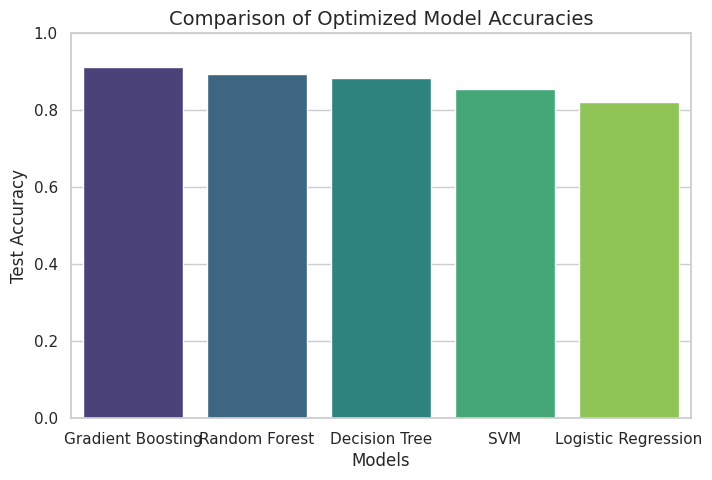

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Collect test accuracies
performance = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

# Create a DataFrame for easy viewing
performance_df = pd.DataFrame.from_dict(performance, orient='index', columns=['Test Accuracy'])
performance_df = performance_df.sort_values(by='Test Accuracy', ascending=False)

print(" Optimized Model Performance Comparison:\n")
print(performance_df)

#  Visualize with a bar plot
plt.figure(figsize=(8,5))
sns.barplot(x=performance_df.index, y=performance_df['Test Accuracy'], palette="viridis")
plt.title("Comparison of Optimized Model Accuracies", fontsize=14)
plt.ylabel("Test Accuracy")
plt.xlabel("Models")
plt.ylim(0, 1)
plt.show()
